# Hardware Heisenberg timing-policy comparison

This notebook runs a small 2-qubit Heisenberg workload on real QUBEX hardware and compares the modern Qiskit-timed execution path with the deprecated `legacy_device_gateway` timing policy.

The same circuit family is used for three curves:

1. ideal local simulation,
2. QUBEX hardware with `timing_policy="qiskit"` and ALAP scheduling,
3. QUBEX hardware with `timing_policy="legacy_device_gateway"`.

The observable is staggered magnetization `(Z0 - Z1) / 2` after starting from `|01>`. `READOUT_MITIGATION=True` enables QUBEX classifier confusion-matrix mitigation through the provider's `backend.run(..., readout_mitigation=True)` option. The default uses `LAYERS = 1`; on the current 144Qv2 pair, `LAYERS = 3` decomposes to 18 CX gates and the algorithmic error dominates the comparison.

By default this notebook connects to hardware. Set `RUN_ON_HARDWARE = False` if you only want compilation, schedule validation, and the ideal simulation.


In [124]:
from __future__ import annotations

import importlib
import importlib.util
import sys
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
from IPython.display import SVG, display
from qiskit import QuantumCircuit, transpile

# Re-running this cell in an existing notebook kernel should pick up local provider edits.
for module_name in (
    "qiskit_qubex_provider.executor",
    "qiskit_qubex_provider.backend",
    "qiskit_qubex_provider.provider",
    "qiskit_qubex_provider",
):
    module = sys.modules.get(module_name)
    if module is not None:
        importlib.reload(module)

from qiskit_qubex_provider import (
    QubexProvider,
    build_pulse_schedule_timeline_figure,
    diff_pulse_schedules,
    summarize_pulse_schedule,
)

HERE = Path.cwd()
if not (HERE / "bell_state.py").exists():
    HERE = Path("examples/hardware").resolve()

spec = importlib.util.spec_from_file_location("hardware_bell_state", HERE / "bell_state.py")
bell_state = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(bell_state)


In [125]:
DEVICE_ID = bell_state.DEFAULT_DEVICE_ID
QUBIT_LABELS = bell_state.DEFAULT_QUBIT_LABELS
BELL_PAIR = bell_state.DEFAULT_BELL_PAIR
CONFIG_ROOT = HERE / "qubex-config"
OUTPUT_DIR = HERE / "generated"

SHOTS = 4096
RUN_ON_HARDWARE = True
READOUT_MITIGATION = True

LAYERS = 1
THETAS = np.linspace(0, np.pi, 13)
THETAS_IDEAL = np.linspace(0, np.pi, 101)
SAMPLE_THETA = np.pi / 2

TOPOLOGY_PATH = bell_state.topology_json_path(
    output_dir=OUTPUT_DIR,
    device_id=DEVICE_ID,
    qubit_labels=QUBIT_LABELS,
)
bell_state.generate_device_topology(
    config_root=CONFIG_ROOT,
    device_id=DEVICE_ID,
    qubit_labels=QUBIT_LABELS,
    bell_pair=BELL_PAIR,
    output_path=TOPOLOGY_PATH,
)

compile_experiment = bell_state.make_experiment(
    config_root=CONFIG_ROOT,
    device_id=DEVICE_ID,
    qubit_labels=QUBIT_LABELS,
)

def provider_from_experiment(experiment, *, timing_policy: str) -> QubexProvider:
    return QubexProvider.from_experiment(
        experiment,
        name=f"{DEVICE_ID}-{timing_policy}",
        device_topology=TOPOLOGY_PATH,
        qubit_labels=QUBIT_LABELS,
        timing_policy=timing_policy,
        execute_options={
            "state_classification": False,
            "time_integration": True,
            "plot": False,
        },
    )

provider_qiskit = provider_from_experiment(compile_experiment, timing_policy="qiskit")
provider_legacy = provider_from_experiment(compile_experiment, timing_policy="legacy_device_gateway")
backend_qiskit = provider_qiskit.get_backend()
backend_legacy = provider_legacy.get_backend()
backend_ideal = QubexProvider(num_qubits=2, coupling_map=[(0, 1)]).get_backend()
initial_layout = bell_state.bell_initial_layout(
    qubit_labels=QUBIT_LABELS,
    bell_pair=BELL_PAIR,
)

print("qiskit backend:", backend_qiskit.name)
print("legacy backend:", backend_legacy.name)
print("topology:", TOPOLOGY_PATH)
print("topology svg:", TOPOLOGY_PATH.with_suffix(".svg"))
print("logical Heisenberg qubits:", BELL_PAIR, "from", QUBIT_LABELS)
print("shots:", SHOTS)
print("run on hardware:", RUN_ON_HARDWARE)
print("readout mitigation:", READOUT_MITIGATION)


date: 2026-06-15 20:13:49
python: 3.13.13
qubex: 1.5.0b4
env: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/.venv
config: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/examples/hardware/qubex-config/144Qv2/config
params: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/examples/hardware/qubex-config/144Qv2/params
chip: 144Qv2 (3rdlotNo6Chip0.0)
qubits: ['Q072', 'Q074', 'Q075']
muxes: ['MUX18']
boxes: ['S137R']


qiskit backend: 144Qv2-qiskit
legacy backend: 144Qv2-legacy_device_gateway
topology: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/examples/hardware/generated/device-topology-144qv2-q072-q074-q075.json
topology svg: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/examples/hardware/generated/device-topology-144qv2-q072-q074-q075.svg
logical Heisenberg qubits: ('Q072', 'Q074') from ('Q072', 'Q074', 'Q075')
shots: 4096
run on hardware: True
readout mitigation: True


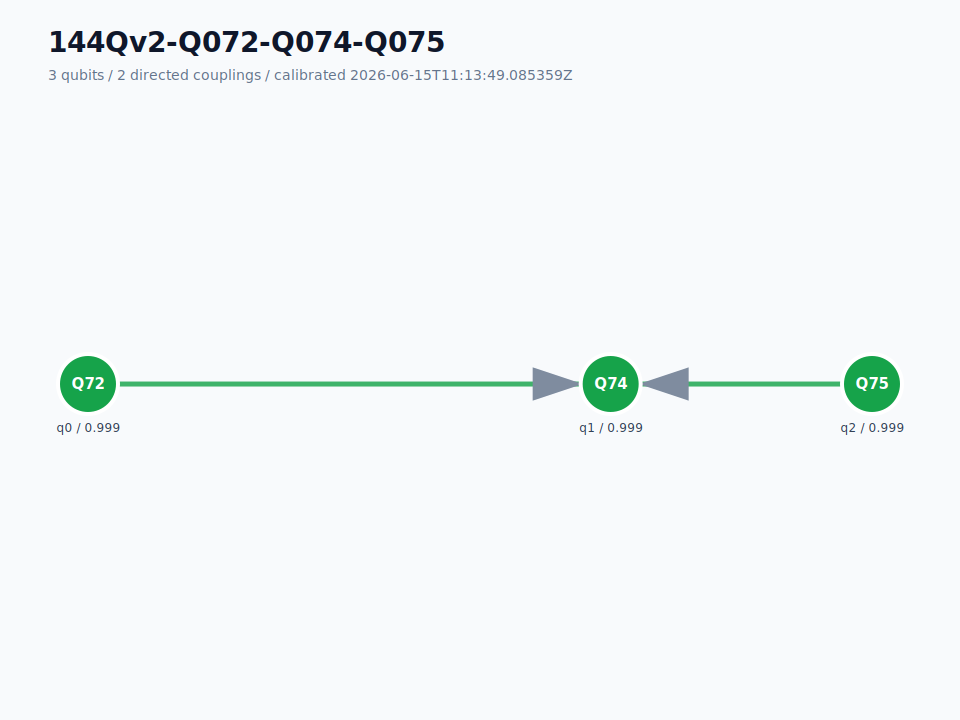

In [126]:
display(SVG(filename=str(TOPOLOGY_PATH.with_suffix(".svg"))))


## 2-qubit Heisenberg workload

The model starts from `|01>` and applies `LAYERS` first-order Heisenberg steps. Keep `LAYERS = 1` for the hardware comparison first; increasing it is useful only after the short-depth curve follows the ideal reference. The total angle `theta` is split across layers:

`exp(-i step XX / 2) exp(-i step YY / 2) exp(-i step ZZ / 2)`

The measured observable is staggered magnetization. Values near `-1` mean the state still looks like `|01>`, while values near `+1` mean it has moved toward `|10>`.


In [127]:
def heisenberg_2q_circuit(theta: float, *, layers: int = LAYERS) -> QuantumCircuit:
    qc = QuantumCircuit(2, 2)
    qc.x(1)
    step = theta / layers
    for _ in range(layers):
        qc.rxx(step, 0, 1)
        qc.ryy(step, 0, 1)
        qc.rzz(step, 0, 1)
    qc.measure([0, 1], [0, 1])
    return qc


def z_expectation(counts: dict[str, int], bit_index: int) -> float:
    total = sum(counts.values())
    value = 0
    for key, n in counts.items():
        bit = key.replace(" ", "")[::-1][bit_index]
        value += n if bit == "0" else -n
    return value / total


def staggered_magnetization(counts: dict[str, int]) -> float:
    return 0.5 * (z_expectation(counts, 0) - z_expectation(counts, 1))


def compile_qiskit(theta: float) -> QuantumCircuit:
    physical = transpile(
        heisenberg_2q_circuit(theta),
        backend_qiskit,
        initial_layout=initial_layout,
        optimization_level=1,
        seed_transpiler=7,
    )
    return transpile(physical, backend_qiskit, scheduling_method="alap", optimization_level=0)


def compile_legacy(theta: float) -> QuantumCircuit:
    return transpile(
        heisenberg_2q_circuit(theta),
        backend_legacy,
        initial_layout=initial_layout,
        optimization_level=1,
        seed_transpiler=7,
    )

heisenberg_2q_circuit(SAMPLE_THETA).draw("text")


┌───────────┐┌───────────┐          ┌─┐   
q_0: ─────┤0          ├┤0          ├─■────────┤M├───
     ┌───┐│  Rxx(π/2) ││  Ryy(π/2) │ │ZZ(π/2) └╥┘┌─┐
q_1: ┤ X ├┤1          ├┤1          ├─■─────────╫─┤M├
     └───┘└───────────┘└───────────┘           ║ └╥┘
c: 2/══════════════════════════════════════════╩══╩═
                                               0  1

## Ideal simulation reference

The local simulator does not model device noise. It gives a reference curve for the hardware measurements.


In [128]:
ideal = []
for theta in THETAS_IDEAL:
    tqc = transpile(heisenberg_2q_circuit(float(theta)), backend_ideal, seed_transpiler=7)
    counts = backend_ideal.run(tqc, shots=SHOTS, seed_simulator=11).result().get_counts()
    ideal.append(staggered_magnetization(counts))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=THETAS_IDEAL,
    y=ideal,
    name="ideal simulation",
    line=dict(color="#475569", dash="dot"),
))
fig.update_layout(
    title="2-qubit Heisenberg ideal reference",
    xaxis=dict(title="total Heisenberg angle theta (rad)"),
    yaxis=dict(title="staggered magnetization", range=[-1.05, 1.05]),
    width=760,
    height=430,
)
fig.show()


## Schedule comparison

`qiskit` consumes the Qiskit scheduled circuit, including explicit start times and explicit readout pulses. `legacy_device_gateway` rebuilds the pulse program through the old sequential path and uses `final_measurement=True` at execution time, so its validated pulse schedule excludes the final readout window. The timelines are useful for seeing the construction difference, but the measured observable is the main comparison.


In [129]:
sample_qiskit = compile_qiskit(SAMPLE_THETA)
sample_legacy = compile_legacy(SAMPLE_THETA)

sample_schedules = {
    "qiskit ALAP": backend_qiskit.validate(sample_qiskit)[0],
    "legacy_device_gateway": backend_legacy.validate(sample_legacy)[0],
}

for name, schedule in sample_schedules.items():
    print(f"\n{name}")
    print(summarize_pulse_schedule(schedule))

print("\nqiskit vs legacy diff")
print(diff_pulse_schedules(sample_schedules["qiskit ALAP"], sample_schedules["legacy_device_gateway"]))



qiskit ALAP
{'Q072': {'duration_ns': 4528.0, 'active_start_ns': 32.0, 'active_end_ns': 3320.0, 'n_samples': 2264}, 'Q074': {'duration_ns': 4528.0, 'active_start_ns': 0.0, 'active_end_ns': 3344.0, 'n_samples': 2264}, 'Q075': {'duration_ns': 4528.0, 'active_start_ns': None, 'active_end_ns': None, 'n_samples': 2264}, 'Q072-Q074': {'duration_ns': 4528.0, 'active_start_ns': 56.0, 'active_end_ns': 3288.0, 'n_samples': 2264}, 'RQ072': {'duration_ns': 4528.0, 'active_start_ns': 3376.0, 'active_end_ns': 4400.0, 'n_samples': 2264}, 'RQ074': {'duration_ns': 4528.0, 'active_start_ns': 3376.0, 'active_end_ns': 4400.0, 'n_samples': 2264}}

legacy_device_gateway
{'Q072': {'duration_ns': 3344.0, 'active_start_ns': 0.0, 'active_end_ns': 3320.0, 'n_samples': 1672}, 'Q074': {'duration_ns': 3344.0, 'active_start_ns': 0.0, 'active_end_ns': 3344.0, 'n_samples': 1672}, 'Q072-Q074': {'duration_ns': 3344.0, 'active_start_ns': 56.0, 'active_end_ns': 3288.0, 'n_samples': 1672}}

qiskit vs legacy diff
{'equal': 

In [130]:
build_pulse_schedule_timeline_figure(sample_schedules["qiskit ALAP"], title="Heisenberg sample: qiskit ALAP").show()


In [131]:
build_pulse_schedule_timeline_figure(sample_schedules["legacy_device_gateway"], title="Heisenberg sample: legacy_device_gateway").show()


In [ ]:
qiskit_circuits = [compile_qiskit(float(theta)) for theta in THETAS]
legacy_circuits = [compile_legacy(float(theta)) for theta in THETAS]


## Hardware sweep: simulation vs qiskit vs legacy

This cell connects to hardware, builds classifiers once, then runs both circuit batches. `READOUT_MITIGATION=True` applies QUBEX's inverse confusion matrix during provider result conversion. The legacy executor does not emit explicit readout pulses for Qiskit `measure`, so the legacy hardware run sets `final_measurement=True`.


In [133]:
hardware_sweep = None
if RUN_ON_HARDWARE:
    experiment = bell_state.make_experiment(
        config_root=CONFIG_ROOT,
        device_id=DEVICE_ID,
        qubit_labels=QUBIT_LABELS,
    )
    try:
        experiment.connect()
        execute_provider_qiskit = provider_from_experiment(experiment, timing_policy="qiskit")
        execute_provider_legacy = provider_from_experiment(experiment, timing_policy="legacy_device_gateway")
        execute_provider_qiskit.build_classifier(targets=list(BELL_PAIR), shots=SHOTS)
        execute_backend_qiskit = execute_provider_qiskit.get_backend()
        execute_backend_legacy = execute_provider_legacy.get_backend()

        qiskit_result = execute_backend_qiskit.run(
            qiskit_circuits,
            shots=SHOTS,
            readout_mitigation=READOUT_MITIGATION,
        ).result()
        legacy_result = execute_backend_legacy.run(
            legacy_circuits,
            shots=SHOTS,
            final_measurement=True,
            readout_mitigation=READOUT_MITIGATION,
        ).result()
        hardware_sweep = {
            "qiskit ALAP": [staggered_magnetization(qiskit_result.get_counts(i)) for i in range(len(qiskit_circuits))],
            "legacy_device_gateway": [staggered_magnetization(legacy_result.get_counts(i)) for i in range(len(legacy_circuits))],
        }
        print(hardware_sweep)
    finally:
        experiment.disconnect()
else:
    print("RUN_ON_HARDWARE is False; hardware sweep was skipped.")


date: 2026-06-15 20:13:49
python: 3.13.13
qubex: 1.5.0b4
env: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/.venv
config: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/examples/hardware/qubex-config/144Qv2/config
params: /home/orangekame3/src/github.com/orangekame3/qiskit-qubex-provider/examples/hardware/qubex-config/144Qv2/params
chip: 144Qv2 (3rdlotNo6Chip0.0)
qubits: ['Q072', 'Q074', 'Q075']
muxes: ['MUX18']
boxes: ['S137R']
Successfully connected.


{'qiskit ALAP': [0.844482421875, 0.51171875, 0.323974609375, 0.043212890625, -0.2919921875, -0.579833984375, -0.6796875, -0.6240234375, -0.37841796875, -0.1162109375, 0.27001953125, 0.517822265625, 0.58447265625], 'legacy_device_gateway': [0.8359375, 0.534912109375, 0.319580078125, 0.02294921875, -0.351806640625, -0.56982421875, -0.662841796875, -0.617919921875, -0.38134765625, -0.05419921875, 0.28564453125, 0.4765625, 0.5810546875]}


In [134]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=THETAS_IDEAL,
    y=ideal,
    name="ideal simulation",
    line=dict(color="#475569", dash="dot"),
))
if hardware_sweep is not None:
    fig.add_trace(go.Scatter(x=THETAS, y=hardware_sweep["qiskit ALAP"], mode="lines+markers", name="qiskit ALAP hardware"))
    fig.add_trace(go.Scatter(x=THETAS, y=hardware_sweep["legacy_device_gateway"], mode="lines+markers", name="legacy hardware"))
fig.update_layout(
    title="2-qubit Heisenberg: simulation vs hardware timing policies",
    xaxis=dict(title="total Heisenberg angle theta (rad)"),
    yaxis=dict(title="staggered magnetization", range=[-1.05, 1.05]),
    width=760,
    height=430,
)
fig.show()
